<a href="https://colab.research.google.com/github/baadddrrr/Python-programming-assignment-/blob/main/KONGfUPANDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SCINTIFIC PROGRAAMMING ASSIGNMENT**

In [16]:
#Import important libs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [11]:

df = pd.read_csv("dataset_student (2).csv")

# 1) Count NaNs
na_counts = df.isna().sum()
print("NaN count by column:\n", na_counts)
print("\nTotal NaNs:", int(na_counts.sum()))

# 2) Show the *type* of NaN in each column that has missing values
print("\nNaN type per column:")
for col in df.columns:
    if df[col].isna().any():
        v = df.loc[df[col].isna(), col].iloc[0]
        print(f"{col}: value={v} | python_type={type(v)}")

# 3) (Optional) show all rows that contain NaNs
print("\nRows with NaNs:")
print(df[df.isna().any(axis=1)])


NaN count by column:
 Year               0
Month              0
Region             0
Consumption_kWh    5
Cost_RM            5
Occupants          5
dtype: int64

Total NaNs: 15

NaN type per column:
Consumption_kWh: value=nan | python_type=<class 'numpy.float64'>
Cost_RM: value=nan | python_type=<class 'numpy.float64'>
Occupants: value=nan | python_type=<class 'numpy.float64'>

Rows with NaNs:
     Year  Month    Region  Consumption_kWh  Cost_RM  Occupants
15   2018      6     Urban           538.97   307.21        NaN
26   2018      9     Rural           289.71   165.14        NaN
44   2019      3     Rural              NaN   191.16        6.0
61   2019      9  Suburban           340.51   194.09        NaN
82   2020      4  Suburban              NaN   263.08        4.0
87   2020      6     Urban           529.89      NaN        4.0
88   2020      6  Suburban           447.14      NaN        5.0
97   2020      9  Suburban              NaN   194.08        6.0
115  2021      3  Suburban 

In [12]:

RATE_RM_PER_KWH = 0.57
df = pd.read_csv("dataset_student (2).csv")

# ---- Fix NaNs (best approach for time-series by region) ----
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df = df.sort_values(["Region", "Date"]).reset_index(drop=True)

df["Consumption_kWh"] = df.groupby("Region")["Consumption_kWh"].transform(
    lambda s: s.interpolate(method="linear", limit_direction="both")
)

df["Occupants"] = df.groupby("Region")["Occupants"].transform(
    lambda s: s.interpolate(method="linear", limit_direction="both")
).round().astype("Int64")

# recompute cost (best consistency)
df["Cost_RM"] = df["Consumption_kWh"] * RATE_RM_PER_KWH

# ---- 1) Summary statistics by region ----
summary = df.groupby("Region").agg(
    mean_consumption=("Consumption_kWh", "mean"),
    median_consumption=("Consumption_kWh", "median"),
    std_consumption=("Consumption_kWh", "std"),
    mean_cost=("Cost_RM", "mean"),
    median_cost=("Cost_RM", "median"),
    std_cost=("Cost_RM", "std"),
).round(3)

print("\nSummary statistics by region:")
print(summary)

# ---- 2) Correlation analysis ----
overall_corr = df["Consumption_kWh"].corr(df["Occupants"].astype(float))
print("\nOverall correlation (Occupants vs Consumption_kWh):", round(overall_corr, 4))

print("\nCorrelation by region:")
for region, g in df.groupby("Region"):
    corr = g["Consumption_kWh"].corr(g["Occupants"].astype(float))
    print(f"{region}: {corr:.4f}")



Summary statistics by region:
          mean_consumption  median_consumption  std_consumption  mean_cost  \
Region                                                                       
Rural              309.817             295.985           72.577    176.595   
Suburban           398.513             407.510           47.620    227.152   
Urban              508.362             501.470           72.793    289.767   

          median_cost  std_cost  
Region                           
Rural         168.711    41.369  
Suburban      232.281    27.143  
Urban         285.838    41.492  

Overall correlation (Occupants vs Consumption_kWh): -0.4652

Correlation by region:
Rural: -0.0234
Suburban: -0.2021
Urban: 0.1064


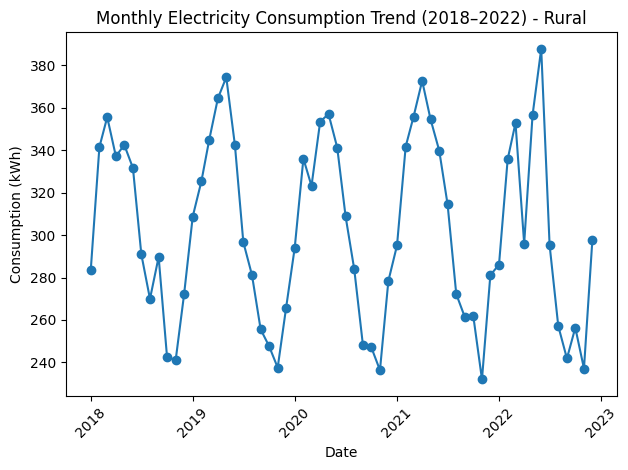

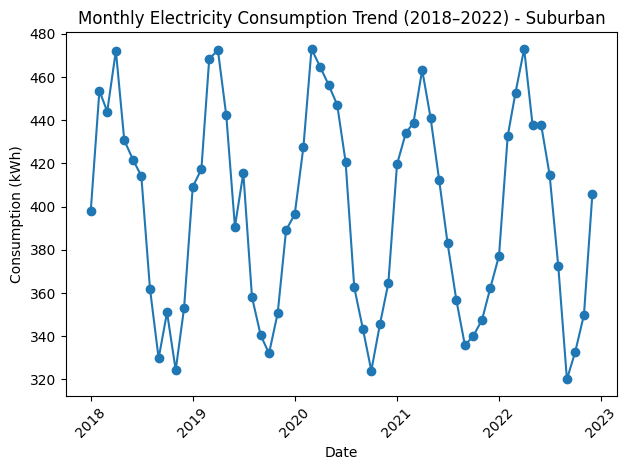

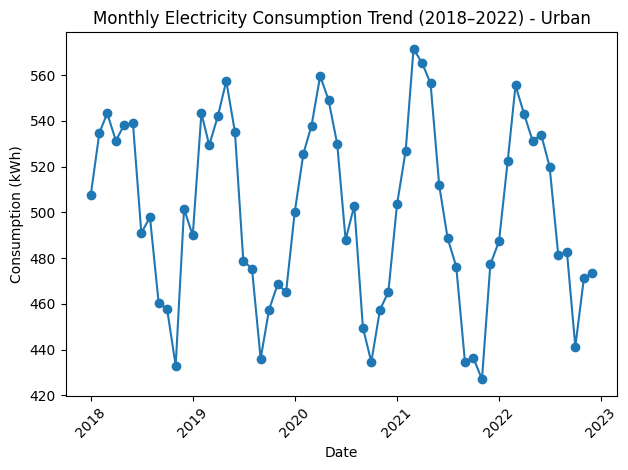

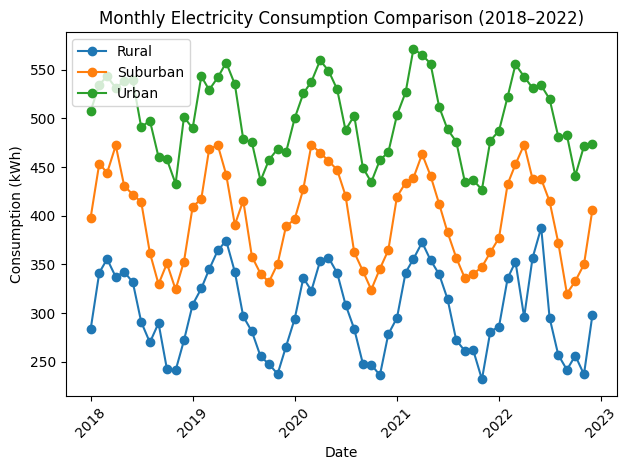

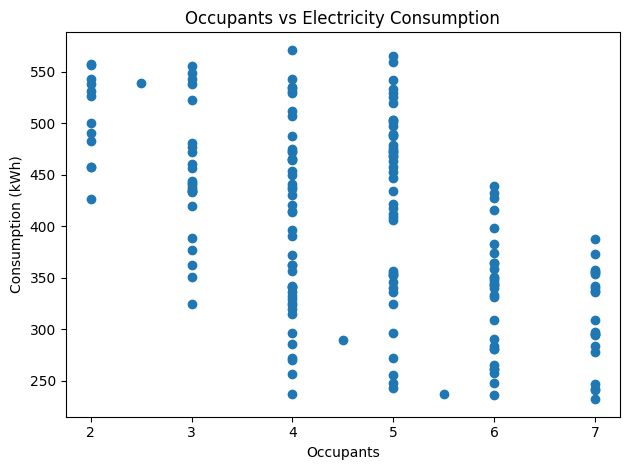

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset (recommended)
df = pd.read_csv("dataset_cleaned.csv")

# Create a proper time axis
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df = df.sort_values(["Region", "Date"]).reset_index(drop=True)

# -------- 1) Trend plot for each region (3 separate plots) --------
for region in df["Region"].unique():
    region_data = df[df["Region"] == region]

    plt.figure()
    plt.plot(region_data["Date"], region_data["Consumption_kWh"], marker="o")
    plt.title(f"Monthly Electricity Consumption Trend (2018–2022) - {region}")
    plt.xlabel("Date")
    plt.ylabel("Consumption (kWh)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -------- 2) Multi-line plot comparing all regions (1 plot) --------
plt.figure()
for region in df["Region"].unique():
    region_data = df[df["Region"] == region]
    plt.plot(region_data["Date"], region_data["Consumption_kWh"], marker="o", label=region)

plt.title("Monthly Electricity Consumption Comparison (2018–2022)")
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# -------- 3) Scatter plot: Occupants vs Consumption (1 plot) --------
plt.figure()
plt.scatter(df["Occupants"], df["Consumption_kWh"])
plt.title("Occupants vs Electricity Consumption")
plt.xlabel("Occupants")
plt.ylabel("Consumption (kWh)")
plt.tight_layout()
plt.show()


R-squared (R²): 1.000
Mean Absolute Error (MAE): 0.00


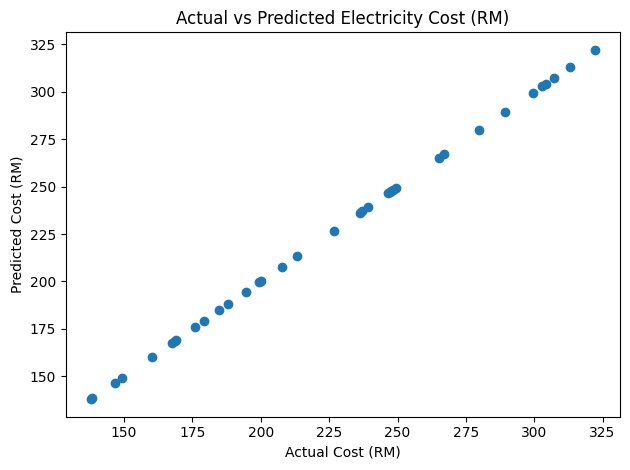


Model coefficients:
Intercept: 0.0
Consumption_kWh coefficient: 0.57
Occupants coefficient: -0.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load cleaned dataset
df = pd.read_csv("dataset_cleaned.csv")

# Features and target
X = df[["Consumption_kWh", "Occupants"]]
y = df["Cost_RM"]

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared (R²): {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Optional: plot actual vs predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Electricity Cost (RM)")
plt.xlabel("Actual Cost (RM)")
plt.ylabel("Predicted Cost (RM)")
plt.tight_layout()
plt.show()

# Optional: show the equation (coefficients)
print("\nModel coefficients:")
print("Intercept:", round(model.intercept_, 4))
print("Consumption_kWh coefficient:", round(model.coef_[0], 4))
print("Occupants coefficient:", round(model.coef_[1], 4))


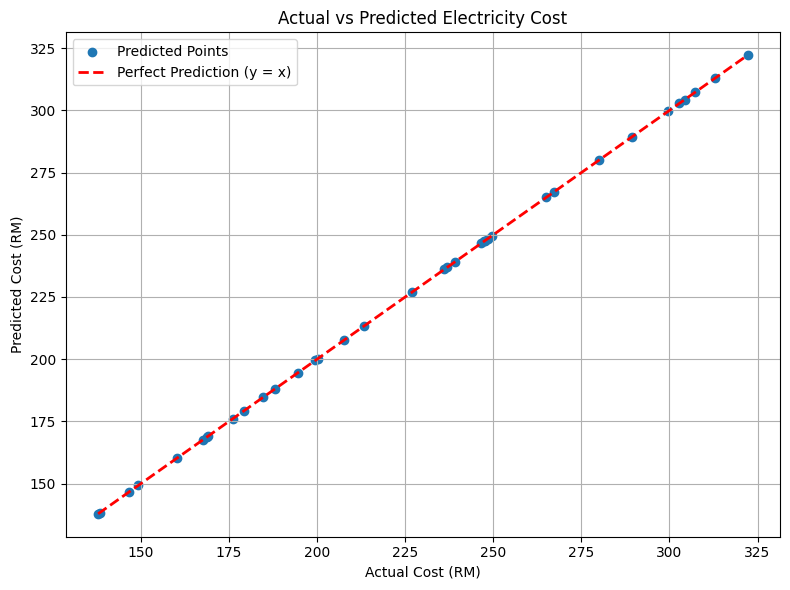

In [15]:


df = pd.read_csv("dataset_cleaned.csv")

X = df[["Consumption_kWh", "Occupants"]]
y = df["Cost_RM"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# --- Plot Actual vs Predicted with perfect prediction line ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, label="Predicted Points")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2,
         label="Perfect Prediction (y = x)")

plt.xlabel("Actual Cost (RM)")
plt.ylabel("Predicted Cost (RM)")
plt.title("Actual vs Predicted Electricity Cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
